#DAE Review-2

#Generic vs Branded Medicine Price Comparison

#1.DATA LOADING &READING

##Import libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


print("Libraries imported successfully")

Libraries imported successfully


##Load the dataset

In [ ]:
import pandas as pd

file_path = "/content/indian_pharmaceutical_products_clean.csv"

df = pd.read_csv(
    file_path,
    engine="python",
    on_bad_lines="skip"
)

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 253973
Columns: 15


##Checking whether the dataset is loaded successfully

In [ ]:
df.head()

,product_id,brand_name,manufacturer,price_inr,is_discontinued,dosage_form,pack_size,pack_unit,num_active_ingredients,primary_ingredient,primary_strength,active_ingredients,therapeutic_class,packaging_raw,manufacturer_raw
0,1,Augmentin 625 Duo Tablet,Glaxo SmithKline Pharmaceuticals Ltd,223.42,False,tablet,10.0,strip,2,Amoxycillin,500mg,"[{'name': 'Amoxycillin', 'strength': '500mg', ...",antibiotic,strip of 10 tablets,Glaxo SmithKline Pharmaceuticals Ltd
1,2,Azithral 500 Tablet,Alembic Pharmaceuticals Ltd,132.36,False,tablet,5.0,strip,1,Azithromycin,500mg,"[{'name': 'Azithromycin', 'strength': '500mg',...",antibiotic,strip of 5 tablets,Alembic Pharmaceuticals Ltd
2,3,Ascoril LS Syrup,Glenmark Pharmaceuticals Ltd,118.00,False,syrup,100.0,bottle,2,Ambroxol,30mg/5ml,"[{'name': 'Ambroxol', 'strength': '30mg/5ml', ...",bronchodilator,bottle of 100 ml Syrup,Glenmark Pharmaceuticals Ltd
3,4,Allegra 120mg Tablet,Sanofi India Ltd,218.81,False,tablet,10.0,strip,1,Fexofenadine,120mg,"[{'name': 'Fexofenadine', 'strength': '120mg',...",antihistamine,strip of 10 tablets,Sanofi India Ltd
4,5,Avil 25 Tablet,Sanofi India Ltd,10.96,False,tablet,15.0,strip,1,Pheniramine,25mg,"[{'name': 'Pheniramine', 'strength': '25mg', '...",other,strip of 15 tablets,Sanofi India Ltd


##Basic information

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253973 entries, 0 to 253972
Data columns (total 15 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   product_id              253973 non-null  int64  
 1   brand_name              253973 non-null  object 
 2   manufacturer            253973 non-null  object 
 3   price_inr               253973 non-null  float64
 4   is_discontinued         253973 non-null  bool   
 5   dosage_form             253973 non-null  object 
 6   pack_size               231643 non-null  float64
 7   pack_unit               231643 non-null  object 
 8   num_active_ingredients  253973 non-null  int64  
 9   primary_ingredient      253973 non-null  object 
 10  primary_strength        228775 non-null  object 
 11  active_ingredients      253973 non-null  object 
 12  therapeutic_class       253973 non-null  object 
 13  packaging_raw           253973 non-null  object 
 14  manufacturer_raw    

##Number of rows and columns

In [ ]:
print("Rows loaded:", len(df))
print("Columns:", len(df.columns))

Rows loaded: 253973
Columns: 15


#2.DATA ACQUISITION & FILTERING

##Check the dataset

In [ ]:
print("Original dataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

Original dataset shape: (253973, 15)

Columns:
['product_id', 'brand_name', 'manufacturer', 'price_inr', 'is_discontinued', 'dosage_form', 'pack_size', 'pack_unit', 'num_active_ingredients', 'primary_ingredient', 'primary_strength', 'active_ingredients', 'therapeutic_class', 'packaging_raw', 'manufacturer_raw']


##Select records useful for our project

In [ ]:
required_columns = [
    "product_id",
    "brand_name",
    "manufacturer",
    "price_inr",
    "is_discontinued",
    "dosage_form",
    "pack_size",
    "pack_unit",
    "primary_ingredient",
    "primary_strength",
    "active_ingredients",
    "therapeutic_class",
    "packaging_raw"
]

df_filtered = df[required_columns].copy()

print("Selected records:", df_filtered.shape)

Selected records: (253973, 13)


##Remove records without price

In [ ]:
df_filtered = df_filtered[
    df_filtered["price_inr"].notna()
].copy()

df_filtered = df_filtered[
    df_filtered["price_inr"] > 0
].copy()

print("Records after valid price filtering:", len(df_filtered))

Records after valid price filtering: 253969


##Keep medicines with composition information

In [ ]:
df_filtered = df_filtered[
    df_filtered["active_ingredients"].notna() &
    df_filtered["primary_ingredient"].notna()
].copy()

print("Records with composition information:", len(df_filtered))

Records with composition information: 253969


##Keep medicines with a name

In [ ]:
df_filtered = df_filtered[
    df_filtered["brand_name"].notna()
].copy()

print("Records with medicine name:", len(df_filtered))

Records with medicine name: 253969


##Remove empty medicine names

In [ ]:
df_filtered = df_filtered[
    df_filtered["brand_name"].astype(str).str.strip() != ""
].copy()

print("Records after name filtering:", len(df_filtered))

Records after name filtering: 253969


##Check important information

In [ ]:
print(
    df_filtered[
        [
            "brand_name",
            "price_inr",
            "primary_ingredient",
            "active_ingredients",
            "primary_strength",
            "dosage_form",
            "pack_size",
            "pack_unit"
        ]
    ].head(10)
)

                        brand_name  price_inr primary_ingredient  \
0         Augmentin 625 Duo Tablet     223.42        Amoxycillin   
1              Azithral 500 Tablet     132.36       Azithromycin   
2                 Ascoril LS Syrup     118.00           Ambroxol   
3             Allegra 120mg Tablet     218.81       Fexofenadine   
4                   Avil 25 Tablet      10.96        Pheniramine   
5                 Allegra-M Tablet     241.48        Montelukast   
6             Amoxyclav 625 Tablet     223.27        Amoxycillin   
7                  Azee 500 Tablet     132.38       Azithromycin   
8               Atarax 25mg Tablet      85.50        Hydroxyzine   
9  Ascoril D Plus Syrup Sugar Free     129.00      Phenylephrine   

                                  active_ingredients primary_strength  \
0  [{'name': 'Amoxycillin', 'strength': '500mg', ...            500mg   
1  [{'name': 'Azithromycin', 'strength': '500mg',...            500mg   
2  [{'name': 'Ambroxol', 'streng

##Check missing values again

In [ ]:
print("Missing values:")
print(
    df_filtered[
        [
            "brand_name",
            "price_inr",
            "primary_ingredient",
            "active_ingredients",
            "primary_strength",
            "dosage_form",
            "pack_size",
            "pack_unit"
        ]
    ].isnull().sum()
)

Missing values:
brand_name                0
price_inr                 0
primary_ingredient        0
active_ingredients        0
primary_strength      25194
dosage_form               0
pack_size             22330
pack_unit             22330
dtype: int64


#3.DATA EXTRACTION

#Extract required columns

In [ ]:
comparison_columns = [
    "product_id",
    "brand_name",
    "manufacturer",
    "price_inr",
    "primary_ingredient",
    "primary_strength",
    "active_ingredients",
    "therapeutic_class",
    "dosage_form",
    "pack_size",
    "pack_unit",
    "packaging_raw"
]

df_extracted = df_filtered[comparison_columns].copy()

print("Extracted dataset shape:", df_extracted.shape)

print("\nColumns extracted:")
print(df_extracted.columns.tolist())

Extracted dataset shape: (253969, 12)

Columns extracted:
['product_id', 'brand_name', 'manufacturer', 'price_inr', 'primary_ingredient', 'primary_strength', 'active_ingredients', 'therapeutic_class', 'dosage_form', 'pack_size', 'pack_unit', 'packaging_raw']


#Normalize medicine names

In [ ]:
df_extracted["medicine_name_key"] = (
    df_extracted["brand_name"]
    .astype(str)
    .str.lower()
    .str.strip()
)

print(
    df_extracted[
        ["brand_name", "medicine_name_key"]
    ].head(10)
)

                        brand_name                medicine_name_key
0         Augmentin 625 Duo Tablet         augmentin 625 duo tablet
1              Azithral 500 Tablet              azithral 500 tablet
2                 Ascoril LS Syrup                 ascoril ls syrup
3             Allegra 120mg Tablet             allegra 120mg tablet
4                   Avil 25 Tablet                   avil 25 tablet
5                 Allegra-M Tablet                 allegra-m tablet
6             Amoxyclav 625 Tablet             amoxyclav 625 tablet
7                  Azee 500 Tablet                  azee 500 tablet
8               Atarax 25mg Tablet               atarax 25mg tablet
9  Ascoril D Plus Syrup Sugar Free  ascoril d plus syrup sugar free


#Normalize manufacturer names

In [ ]:
df_extracted["manufacturer_key"] = (
    df_extracted["manufacturer"]
    .astype(str)
    .str.lower()
    .str.strip()
)

print(
    df_extracted[
        ["manufacturer", "manufacturer_key"]
    ].head(10)
)

                           manufacturer                      manufacturer_key
0  Glaxo SmithKline Pharmaceuticals Ltd  glaxo smithkline pharmaceuticals ltd
1           Alembic Pharmaceuticals Ltd           alembic pharmaceuticals ltd
2          Glenmark Pharmaceuticals Ltd          glenmark pharmaceuticals ltd
3                      Sanofi India Ltd                      sanofi india ltd
4                      Sanofi India Ltd                      sanofi india ltd
5                      Sanofi India Ltd                      sanofi india ltd
6                                Abbott                                abbott
7                             Cipla Ltd                             cipla ltd
8           Dr Reddy's Laboratories Ltd           dr reddy's laboratories ltd
9          Glenmark Pharmaceuticals Ltd          glenmark pharmaceuticals ltd


#Normalize the primary ingredient

In [ ]:
df_extracted["ingredient_key"] = (
    df_extracted["primary_ingredient"]
    .astype(str)
    .str.lower()
    .str.strip()
)

print(
    df_extracted[
        ["primary_ingredient", "ingredient_key"]
    ].head(10)
)

  primary_ingredient ingredient_key
0        Amoxycillin    amoxycillin
1       Azithromycin   azithromycin
2           Ambroxol       ambroxol
3       Fexofenadine   fexofenadine
4        Pheniramine    pheniramine
5        Montelukast    montelukast
6        Amoxycillin    amoxycillin
7       Azithromycin   azithromycin
8        Hydroxyzine    hydroxyzine
9      Phenylephrine  phenylephrine


#Normalize strength

In [ ]:
df_extracted["strength_key"] = (
    df_extracted["primary_strength"]
    .fillna("unknown")
    .astype(str)
    .str.lower()
    .str.strip()
)

print(
    df_extracted[
        ["primary_strength", "strength_key"]
    ].head(10)
)

  primary_strength strength_key
0            500mg        500mg
1            500mg        500mg
2         30mg/5ml     30mg/5ml
3            120mg        120mg
4             25mg         25mg
5             10mg         10mg
6            500mg        500mg
7            500mg        500mg
8             25mg         25mg
9              5mg          5mg


#Normalize dosage form

In [ ]:
df_extracted["dosage_form_key"] = (
    df_extracted["dosage_form"]
    .astype(str)
    .str.lower()
    .str.strip()
)

print(
    df_extracted[
        ["dosage_form", "dosage_form_key"]
    ].head(10)
)

  dosage_form dosage_form_key
0      tablet          tablet
1      tablet          tablet
2       syrup           syrup
3      tablet          tablet
4      tablet          tablet
5      tablet          tablet
6      tablet          tablet
7      tablet          tablet
8      tablet          tablet
9       syrup           syrup


#Create the comparison group

In [ ]:
df_extracted["comparison_group"] = (
    df_extracted["ingredient_key"] + "|" +
    df_extracted["strength_key"] + "|" +
    df_extracted["dosage_form_key"]
)

print(
    df_extracted[
        [
            "brand_name",
            "primary_ingredient",
            "primary_strength",
            "dosage_form",
            "comparison_group"
        ]
    ].head(10)
)

                        brand_name primary_ingredient primary_strength  \
0         Augmentin 625 Duo Tablet        Amoxycillin            500mg   
1              Azithral 500 Tablet       Azithromycin            500mg   
2                 Ascoril LS Syrup           Ambroxol         30mg/5ml   
3             Allegra 120mg Tablet       Fexofenadine            120mg   
4                   Avil 25 Tablet        Pheniramine             25mg   
5                 Allegra-M Tablet        Montelukast             10mg   
6             Amoxyclav 625 Tablet        Amoxycillin            500mg   
7                  Azee 500 Tablet       Azithromycin            500mg   
8               Atarax 25mg Tablet        Hydroxyzine             25mg   
9  Ascoril D Plus Syrup Sugar Free      Phenylephrine              5mg   

  dosage_form           comparison_group  
0      tablet   amoxycillin|500mg|tablet  
1      tablet  azithromycin|500mg|tablet  
2       syrup    ambroxol|30mg/5ml|syrup  
3      tablet

#Inspect manufacturers

In [ ]:
print("Number of unique manufacturers:")

print(
    df_extracted["manufacturer"]
    .nunique()
)

print("\nSample manufacturers:")

print(
    df_extracted["manufacturer"]
    .value_counts()
    .head(30)
)

Number of unique manufacturers:
7647

Sample manufacturers:
manufacturer
Sun Pharmaceutical Industries Ltd    2986
Cipla Ltd                            2467
Intas Pharmaceuticals Ltd            2302
Torrent Pharmaceuticals Ltd          2027
Alkem Laboratories Ltd               1809
Abbott                               1777
Zydus Cadila                         1768
Lupin Ltd                            1735
Micro Labs Ltd                       1305
Mankind Pharma Ltd                   1297
Macleods Pharmaceuticals Pvt Ltd     1165
Glenmark Pharmaceuticals Ltd         1131
Leeford Healthcare Ltd               1068
Dr Reddy's Laboratories Ltd           996
Cadila Pharmaceuticals Ltd            971
Emcure Pharmaceuticals Ltd            945
Alembic Pharmaceuticals Ltd           839
Ipca Laboratories Ltd                 806
Ajanta Pharma Ltd                     758
Wockhardt Ltd                         707
Elder Pharmaceuticals Ltd             705
Aristo Pharmaceuticals Pvt Ltd        676
Eas

#Inspect medicine names

In [ ]:
print("Number of unique medicine names:")

print(
    df_extracted["brand_name"]
    .nunique()
)

print("\nSample medicine names:")

print(
    df_extracted["brand_name"]
    .head(50)
    .to_string(index=False)
)

Number of unique medicine names:
249394

Sample medicine names:
              Augmentin 625 Duo Tablet
                   Azithral 500 Tablet
                      Ascoril LS Syrup
                  Allegra 120mg Tablet
                        Avil 25 Tablet
                      Allegra-M Tablet
                  Amoxyclav 625 Tablet
                       Azee 500 Tablet
                    Atarax 25mg Tablet
       Ascoril D Plus Syrup Sugar Free
                     Aciloc 150 Tablet
                            Alex Syrup
                         Anovate Cream
         Augmentin Duo Oral Suspension
                      Ambrodil-S Syrup
                        Arkamin Tablet
                        Avomine Tablet
         Asthakind-DX Syrup Sugar Free
                  Allegra 180mg Tablet
              Albendazole 400mg Tablet
                        Asthalin Syrup
                    Alprax 0.25 Tablet
                   Altraday Capsule SR
                     Ativan 2mg Tablet


#Check manufacturer vs medicine names

In [ ]:
manufacturer_name_check = df_extracted[
    [
        "brand_name",
        "manufacturer",
        "price_inr",
        "primary_ingredient",
        "primary_strength"
    ]
].head(30)

print(manufacturer_name_check.to_string(index=False))

                     brand_name                         manufacturer  price_inr primary_ingredient primary_strength
       Augmentin 625 Duo Tablet Glaxo SmithKline Pharmaceuticals Ltd     223.42        Amoxycillin            500mg
            Azithral 500 Tablet          Alembic Pharmaceuticals Ltd     132.36       Azithromycin            500mg
               Ascoril LS Syrup         Glenmark Pharmaceuticals Ltd     118.00           Ambroxol         30mg/5ml
           Allegra 120mg Tablet                     Sanofi India Ltd     218.81       Fexofenadine            120mg
                 Avil 25 Tablet                     Sanofi India Ltd      10.96        Pheniramine             25mg
               Allegra-M Tablet                     Sanofi India Ltd     241.48        Montelukast             10mg
           Amoxyclav 625 Tablet                               Abbott     223.27        Amoxycillin            500mg
                Azee 500 Tablet                            Cipla Ltd    

#4.Data Validation & Cleaning

#Check missing values

In [ ]:
print("Missing values before cleaning:")

print(
    df_extracted[
        [
            "brand_name",
            "manufacturer",
            "price_inr",
            "primary_ingredient",
            "primary_strength",
            "active_ingredients",
            "dosage_form",
            "pack_size",
            "pack_unit"
        ]
    ].isnull().sum()
)

Missing values before cleaning:
brand_name                0
manufacturer              0
price_inr                 0
primary_ingredient        0
primary_strength      25194
active_ingredients        0
dosage_form               0
pack_size             22330
pack_unit             22330
dtype: int64


#Check invalid prices

In [ ]:
invalid_prices = df_extracted[
    df_extracted["price_inr"].isna() |
    (df_extracted["price_inr"] <= 0)
]

print("Number of invalid prices:", len(invalid_prices))

Number of invalid prices: 0


In [ ]:
df_clean = df_extracted[
    df_extracted["price_inr"].notna() &
    (df_extracted["price_inr"] > 0)
].copy()

print("Records after price validation:", len(df_clean))

Records after price validation: 253969


#Check missing strength

In [ ]:
missing_strength = df_clean[
    df_clean["strength_key"] == "unknown"
]

print("Medicines with missing strength:", len(missing_strength))

Medicines with missing strength: 25194


#Remove records with unknown strength

In [ ]:
df_clean = df_clean[
    df_clean["strength_key"] != "unknown"
].copy()

print("Records after strength validation:", len(df_clean))

Records after strength validation: 228775


#Check duplicate Product IDs

In [ ]:
duplicate_ids = df_clean[
    df_clean["product_id"].duplicated(keep=False)
]

print("Duplicate product IDs:", len(duplicate_ids))

Duplicate product IDs: 0


In [ ]:
df_clean = df_clean.drop_duplicates(
    subset=["product_id"]
).copy()

print("Records after duplicate ID removal:", len(df_clean))

Records after duplicate ID removal: 228775


#Check duplicate medicine names

In [ ]:
duplicate_names = df_clean["medicine_name_key"].value_counts()

print("Medicine names appearing more than once:")

print(
    duplicate_names[
        duplicate_names > 1
    ].head(20)
)

Medicine names appearing more than once:
medicine_name_key
ringer lactate infusion              9
leflox 500mg tablet                  5
azilife 500mg tablet                 5
meditrax s 1000mg/500mg injection    4
lc 5mg tablet                        4
looz oral solution                   4
meditrax 1000mg injection            4
itracare 200mg capsule               4
zydexa plus 4mg injection            4
cefpoxim dry syrup                   4
andy 50mg injection                  3
atorfit 10 tablet                    3
vomikit 4mg tablet md                3
azbact 100mg tablet dt               3
roxim 150mg tablet                   3
top 40mg tablet                      3
oxin 200mg tablet                    3
reflox 200mg tablet                  3
sefix 100mg tablet                   3
dekadron injection                   3
Name: count, dtype: int64


#Validate comparison groups

In [ ]:
group_counts = (
    df_clean
    .groupby("comparison_group")
    .size()
    .reset_index(name="medicine_count")
)

print("Comparison group summary:")

print(group_counts.head(10))

Comparison group summary:
                      comparison_group  medicine_count
0                abacavir|300mg|tablet               4
1                abacavir|600mg|tablet               6
2               abatacept|250mg|powder               1
3             abciximab|10mg|injection               3
4             abemaciclib|100mg|tablet               1
5             abemaciclib|150mg|tablet               1
6             abemaciclib|200mg|tablet               2
7  abiraterone acetate|250mg|injection               1
8     abiraterone acetate|250mg|tablet              37
9     abiraterone acetate|500mg|tablet              14


#Identify groups containing at least 2 medicines

In [ ]:
valid_groups = group_counts[
    group_counts["medicine_count"] >= 2
]["comparison_group"]

print("Number of comparison groups with at least 2 medicines:",
      len(valid_groups))

Number of comparison groups with at least 2 medicines: 4344


#Create the comparison-ready dataset

In [ ]:
df_comparison = df_clean[
    df_clean["comparison_group"].isin(valid_groups)
].copy()

print("Comparison-ready records:", len(df_comparison))

print(
    "Comparison groups:",
    df_comparison["comparison_group"].nunique()
)

Comparison-ready records: 225731
Comparison groups: 4344


#Final validation

In [ ]:
print("FINAL DATA VALIDATION")
print("---------------------")

print("Rows:", len(df_comparison))
print("Columns:", len(df_comparison.columns))

print(
    "Unique Product IDs:",
    df_comparison["product_id"].nunique()
)

print(
    "Unique Comparison Groups:",
    df_comparison["comparison_group"].nunique()
)

print(
    "Missing Prices:",
    df_comparison["price_inr"].isna().sum()
)

print(
    "Unknown Strengths:",
    (df_comparison["strength_key"] == "unknown").sum()
)

print(
    "Duplicate Product IDs:",
    df_comparison["product_id"].duplicated().sum()
)

FINAL DATA VALIDATION
---------------------
Rows: 225731
Columns: 18
Unique Product IDs: 225731
Unique Comparison Groups: 4344
Missing Prices: 0
Unknown Strengths: 0
Duplicate Product IDs: 0


#Display the cleaned data

In [ ]:
df_comparison[
    [
        "product_id",
        "brand_name",
        "manufacturer",
        "price_inr",
        "primary_ingredient",
        "primary_strength",
        "dosage_form",
        "comparison_group"
    ]
].head(20)

,product_id,brand_name,manufacturer,price_inr,primary_ingredient,primary_strength,dosage_form,comparison_group
0,1,Augmentin 625 Duo Tablet,Glaxo SmithKline Pharmaceuticals Ltd,223.42,Amoxycillin,500mg,tablet,amoxycillin|500mg|tablet
1,2,Azithral 500 Tablet,Alembic Pharmaceuticals Ltd,132.36,Azithromycin,500mg,tablet,azithromycin|500mg|tablet
2,3,Ascoril LS Syrup,Glenmark Pharmaceuticals Ltd,118.00,Ambroxol,30mg/5ml,syrup,ambroxol|30mg/5ml|syrup
3,4,Allegra 120mg Tablet,Sanofi India Ltd,218.81,Fexofenadine,120mg,tablet,fexofenadine|120mg|tablet
4,5,Avil 25 Tablet,Sanofi India Ltd,10.96,Pheniramine,25mg,tablet,pheniramine|25mg|tablet
5,6,Allegra-M Tablet,Sanofi India Ltd,241.48,Montelukast,10mg,tablet,montelukast|10mg|tablet
6,7,Amoxyclav 625 Tablet,Abbott,223.27,Amoxycillin,500mg,tablet,amoxycillin|500mg|tablet
7,8,Azee 500 Tablet,Cipla Ltd,132.38,Azithromycin,500mg,tablet,azithromycin|500mg|tablet
8,9,Atarax 25mg Tablet,Dr Reddy's Laboratories Ltd,85.50,Hydroxyzine,25mg,tablet,hydroxyzine|25mg|tablet
9,10,Ascoril D Plus Syrup Sugar Free,Glenmark Pharmaceuticals Ltd,129.00,Phenylephrine,5mg,syrup,phenylephrine|5mg|syrup


#5.Data Aggregation & Representation

#Count medicines in each comparison group

In [ ]:
group_counts = (
    df_comparison
    .groupby("comparison_group")
    .size()
    .reset_index(name="medicine_count")
)

print("Comparison Group Counts:")
print(group_counts.head(10))

Comparison Group Counts:
                   comparison_group  medicine_count
0             abacavir|300mg|tablet               4
1             abacavir|600mg|tablet               6
2          abciximab|10mg|injection               3
3          abemaciclib|200mg|tablet               2
4  abiraterone acetate|250mg|tablet              37
5  abiraterone acetate|500mg|tablet              14
6          acamprosate|333mg|tablet               8
7             acarbose|100mg|tablet               2
8              acarbose|25mg|tablet              39
9              acarbose|50mg|tablet              43


#Create the aggregated price

In [ ]:
group_summary = (
    df_comparison
    .groupby("comparison_group")
    .agg(
        medicine_count=("product_id", "count"),
        minimum_price=("price_inr", "min"),
        maximum_price=("price_inr", "max"),
        average_price=("price_inr", "mean")
    )
    .reset_index()
)

print("Aggregated Comparison Summary:")
print(group_summary.head(10))

Aggregated Comparison Summary:
                   comparison_group  medicine_count  minimum_price  \
0             abacavir|300mg|tablet               4        1550.64   
1             abacavir|600mg|tablet               6        1486.00   
2          abciximab|10mg|injection               3        8100.00   
3          abemaciclib|200mg|tablet               2       11938.00   
4  abiraterone acetate|250mg|tablet              37        6930.00   
5  abiraterone acetate|500mg|tablet              14       13000.00   
6          acamprosate|333mg|tablet               8          99.21   
7             acarbose|100mg|tablet               2          91.27   
8              acarbose|25mg|tablet              39          28.00   
9              acarbose|50mg|tablet              43          31.85   

   maximum_price  average_price  
0        7215.00    3287.450000  
1        5832.85    2986.365000  
2       22629.00   13343.000000  
3       23876.00   17907.000000  
4      150000.00   36308.248

#Calculate price variation

In [ ]:
group_summary["price_difference"] = (
    group_summary["maximum_price"] -
    group_summary["minimum_price"]
)

print(group_summary.head(10))

                   comparison_group  medicine_count  minimum_price  \
0             abacavir|300mg|tablet               4        1550.64   
1             abacavir|600mg|tablet               6        1486.00   
2          abciximab|10mg|injection               3        8100.00   
3          abemaciclib|200mg|tablet               2       11938.00   
4  abiraterone acetate|250mg|tablet              37        6930.00   
5  abiraterone acetate|500mg|tablet              14       13000.00   
6          acamprosate|333mg|tablet               8          99.21   
7             acarbose|100mg|tablet               2          91.27   
8              acarbose|25mg|tablet              39          28.00   
9              acarbose|50mg|tablet              43          31.85   

   maximum_price  average_price  price_difference  
0        7215.00    3287.450000           5664.36  
1        5832.85    2986.365000           4346.85  
2       22629.00   13343.000000          14529.00  
3       23876.00   17

#Calculate percentage price variation

In [ ]:
group_summary["price_difference_percent"] = (
    group_summary["price_difference"] /
    group_summary["maximum_price"]
) * 100

print(group_summary.head(10))

                   comparison_group  medicine_count  minimum_price  \
0             abacavir|300mg|tablet               4        1550.64   
1             abacavir|600mg|tablet               6        1486.00   
2          abciximab|10mg|injection               3        8100.00   
3          abemaciclib|200mg|tablet               2       11938.00   
4  abiraterone acetate|250mg|tablet              37        6930.00   
5  abiraterone acetate|500mg|tablet              14       13000.00   
6          acamprosate|333mg|tablet               8          99.21   
7             acarbose|100mg|tablet               2          91.27   
8              acarbose|25mg|tablet              39          28.00   
9              acarbose|50mg|tablet              43          31.85   

   maximum_price  average_price  price_difference  price_difference_percent  
0        7215.00    3287.450000           5664.36                 78.508108  
1        5832.85    2986.365000           4346.85                 74.5236

#Sort the groups

In [ ]:
group_summary_sorted = group_summary.sort_values(
    "price_difference",
    ascending=False
)

print("Groups with highest observed price differences:")
print(group_summary_sorted.head(20))

Groups with highest observed price differences:
                       comparison_group  medicine_count  minimum_price  \
2079            ibrutinib|140mg|capsule              11        7200.00   
1644          enzalutamide|40mg|capsule              14         856.42   
1277              dasatinib|70mg|tablet              10        4450.00   
1276              dasatinib|50mg|tablet              17        2398.00   
3271         pemetrexed|500mg|injection              19        2442.46   
3897             sorafenib|200mg|tablet               8        1985.00   
4      abiraterone acetate|250mg|tablet              37        6930.00   
618       cabazitaxel|60mg/ml|injection               5       11041.92   
516         bevacizumab|400mg|injection              16       35120.00   
1275              dasatinib|20mg|tablet               9        1095.00   
4119             tofacitinib|5mg|tablet              30         320.00   
3962             sunitinib|50mg|capsule               9        1

#Create the detailed representation

In [ ]:
medicine_representation = df_comparison[
    [
        "product_id",
        "brand_name",
        "manufacturer",
        "price_inr",
        "primary_ingredient",
        "primary_strength",
        "dosage_form",
        "pack_size",
        "pack_unit",
        "comparison_group"
    ]
].copy()

print("Medicine Representation:")
print(medicine_representation.head(20))

Medicine Representation:
    product_id                       brand_name  \
0            1         Augmentin 625 Duo Tablet   
1            2              Azithral 500 Tablet   
2            3                 Ascoril LS Syrup   
3            4             Allegra 120mg Tablet   
4            5                   Avil 25 Tablet   
5            6                 Allegra-M Tablet   
6            7             Amoxyclav 625 Tablet   
7            8                  Azee 500 Tablet   
8            9               Atarax 25mg Tablet   
9           10  Ascoril D Plus Syrup Sugar Free   
10          11                Aciloc 150 Tablet   
11          12                       Alex Syrup   
13          14    Augmentin Duo Oral Suspension   
14          15                 Ambrodil-S Syrup   
16          17                   Avomine Tablet   
17          18    Asthakind-DX Syrup Sugar Free   
18          19             Allegra 180mg Tablet   
19          20         Albendazole 400mg Tablet   
20    

#Sort medicines within each group

In [ ]:
medicine_representation = medicine_representation.sort_values(
    [
        "comparison_group",
        "price_inr"
    ]
).reset_index(drop=True)

print(medicine_representation.head(20))

    product_id                      brand_name  \
0         1957                  Abamune Tablet   
1         4975                    A-Bec Tablet   
2         9482             ABHOPE 300MG TABLET   
3       236242              Virol 300mg Tablet   
4         3740                  Albavir Tablet   
5         6487                  Albavir Tablet   
6         2296  Abamune L 600 mg/300 mg Tablet   
7         6233                   Abalam Tablet   
8         7370      A Bec L 600mg/300mg Tablet   
9       108303                    Inbec Tablet   
10        3418        Abcixirel 10mg Injection   
11       87242          Faximab 10mg Injection   
12      187643           Reopro 10mg Injection   
13      190816            Ramiven 200mg Tablet   
14      187040            Ramiven 200mg Tablet   
15        8568             Abtmed 250mg Tablet   
16       16170           Abatitor 250mg Tablet   
17      246642             Zelgor 250mg Tablet   
18        3811              Abura 250mg Tablet   


#Create a simple Group ID

In [ ]:
group_id_map = {
    group: i + 1
    for i, group in enumerate(
        medicine_representation["comparison_group"].unique()
    )
}

medicine_representation["group_id"] = (
    medicine_representation["comparison_group"]
    .map(group_id_map)
)

print(medicine_representation.head(20))

    product_id                      brand_name  \
0         1957                  Abamune Tablet   
1         4975                    A-Bec Tablet   
2         9482             ABHOPE 300MG TABLET   
3       236242              Virol 300mg Tablet   
4         3740                  Albavir Tablet   
5         6487                  Albavir Tablet   
6         2296  Abamune L 600 mg/300 mg Tablet   
7         6233                   Abalam Tablet   
8         7370      A Bec L 600mg/300mg Tablet   
9       108303                    Inbec Tablet   
10        3418        Abcixirel 10mg Injection   
11       87242          Faximab 10mg Injection   
12      187643           Reopro 10mg Injection   
13      190816            Ramiven 200mg Tablet   
14      187040            Ramiven 200mg Tablet   
15        8568             Abtmed 250mg Tablet   
16       16170           Abatitor 250mg Tablet   
17      246642             Zelgor 250mg Tablet   
18        3811              Abura 250mg Tablet   


#Create the final Part 5 dataset

In [ ]:
df_aggregated = medicine_representation[
    [
        "group_id",
        "comparison_group",
        "product_id",
        "brand_name",
        "manufacturer",
        "price_inr",
        "primary_ingredient",
        "primary_strength",
        "dosage_form",
        "pack_size",
        "pack_unit"
    ]
].copy()

print("Final Part 5 Dataset:")
print(df_aggregated.head(20))

Final Part 5 Dataset:
    group_id                  comparison_group  product_id  \
0          1             abacavir|300mg|tablet        1957   
1          1             abacavir|300mg|tablet        4975   
2          1             abacavir|300mg|tablet        9482   
3          1             abacavir|300mg|tablet      236242   
4          2             abacavir|600mg|tablet        3740   
5          2             abacavir|600mg|tablet        6487   
6          2             abacavir|600mg|tablet        2296   
7          2             abacavir|600mg|tablet        6233   
8          2             abacavir|600mg|tablet        7370   
9          2             abacavir|600mg|tablet      108303   
10         3          abciximab|10mg|injection        3418   
11         3          abciximab|10mg|injection       87242   
12         3          abciximab|10mg|injection      187643   
13         4          abemaciclib|200mg|tablet      190816   
14         4          abemaciclib|200mg|tablet  

#6.DATA ANALYSIS

#Create Analysis Dataset

In [ ]:
# Create a separate dataset for analysis

df_analysis = df_aggregated.copy()

print("Analysis dataset shape:", df_analysis.shape)

Analysis dataset shape: (225731, 11)


#Clean Medicine Names

In [ ]:
import re

def clean_medicine_name(name):

    name = str(name).lower().strip()

    # Remove strength values
    name = re.sub(
        r'\b\d+(\.\d+)?\s*(mg|mcg|g|kg|ml|l|%|iu)\b',
        '',
        name
    )

    # Remove dosage/form-related words
    dosage_words = [
        "tablet", "tablets",
        "capsule", "capsules",
        "syrup", "suspension",
        "injection", "infusion",
        "cream", "ointment",
        "gel", "drops",
        "solution", "powder",
        "inhaler", "softgel",
        "oral", "dry", "junior"
    ]

    for word in dosage_words:
        name = re.sub(
            r'\b' + word + r'\b',
            '',
            name
        )

    # Remove extra spaces
    name = re.sub(r'\s+', ' ', name).strip()

    return name


# Apply cleaning to medicine names
df_analysis["name_core"] = (
    df_analysis["brand_name"]
    .apply(clean_medicine_name)
)


# Clean primary ingredient names
df_analysis["ingredient_clean"] = (
    df_analysis["primary_ingredient"]
    .astype(str)
    .str.lower()
    .str.strip()
)

print("Medicine name cleaning completed.")

Medicine name cleaning completed.


#Determine Medicine Type

In [ ]:
# Check whether the cleaned medicine name
# matches the primary ingredient

df_analysis["name_core_matches_ingredient"] = (
    df_analysis["name_core"]
    ==
    df_analysis["ingredient_clean"]
)


# Assign project-defined medicine type

df_analysis["medicine_type"] = "Potential Branded"

df_analysis.loc[
    df_analysis["name_core_matches_ingredient"],
    "medicine_type"
] = "Potential Generic"

In [ ]:
medicine_type_counts = (
    df_analysis["medicine_type"]
    .value_counts()
    .reset_index()
)

medicine_type_counts.columns = [
    "medicine_type",
    "count"
]

print(medicine_type_counts)

       medicine_type   count
0  Potential Branded  225672
1  Potential Generic      59


#Extract Potential Generic Candidates

In [ ]:
generic_candidates = df_analysis[
    df_analysis["medicine_type"] == "Potential Generic"
].copy()

print(
    "Potential Generic Candidates:",
    len(generic_candidates)
)

Potential Generic Candidates: 59


In [ ]:
print(
    generic_candidates[
        [
            "brand_name",
            "primary_ingredient",
            "manufacturer",
            "price_inr",
            "primary_strength",
            "dosage_form",
            "comparison_group",
            "medicine_type"
        ]
    ].to_string(index=False)
)

                         brand_name   primary_ingredient                          manufacturer  price_inr primary_strength dosage_form                    comparison_group     medicine_type
            Adenosine 3mg Injection            Adenosine         Samarth Life Sciences Pvt Ltd     208.02              3mg   injection             adenosine|3mg|injection Potential Generic
           Albendazole 400mg Tablet          Albendazole            Cadila Pharmaceuticals Ltd       9.58            400mg      tablet            albendazole|400mg|tablet Potential Generic
                   Alfuzosin Tablet            Alfuzosin         Care Formulation Labs Pvt Ltd     165.00             10mg      tablet               alfuzosin|10mg|tablet Potential Generic
           Amikacin 250mg Injection             Amikacin          Prem Pharmaceuticals Pvt Ltd      38.70            250mg   injection            amikacin|250mg|injection Potential Generic
  Amoxycillin 125mg Oral Suspension          Amoxycilli

#Identify Comparison Groups

In [ ]:
generic_groups = (
    generic_candidates["comparison_group"]
    .unique()
)

print(
    "Comparison groups containing potential generic candidates:",
    len(generic_groups)
)

Comparison groups containing potential generic candidates: 56


#Separate Other Products in Those Groups

In [ ]:
other_products = df_analysis[
    df_analysis["comparison_group"].isin(generic_groups)
    &
    (df_analysis["medicine_type"] == "Potential Branded")
].copy()

print(
    "Potential Generic Candidates:",
    len(generic_candidates)
)

print(
    "Other Products:",
    len(other_products)
)

Potential Generic Candidates: 59
Other Products: 6993


#Calculate Average Comparison Price

In [ ]:
other_group_average = (
    other_products
    .groupby("comparison_group")["price_inr"]
    .mean()
    .reset_index(name="average_other_price")
)

print(
    other_group_average.head(10)
)

               comparison_group  average_other_price
0       adenosine|3mg|injection           216.296667
1      albendazole|400mg|tablet            30.932322
2         alfuzosin|10mg|tablet           174.442941
3      amikacin|250mg|injection            37.606587
4  amoxycillin|125mg|suspension            42.356129
5       amoxycillin|125mg|syrup            39.952837
6      amoxycillin|125mg|tablet            26.670000
7     amoxycillin|250mg|capsule            54.905263
8      amoxycillin|250mg|tablet           100.263695
9     amoxycillin|500mg|capsule            68.925154


In [ ]:
price_comparison = generic_candidates[
    [
        "comparison_group",
        "brand_name",
        "manufacturer",
        "price_inr"
    ]
].copy()

price_comparison = price_comparison.merge(
    other_group_average,
    on="comparison_group",
    how="left"
)

print(
    price_comparison.head(10)
)

               comparison_group                         brand_name  \
0       adenosine|3mg|injection            Adenosine 3mg Injection   
1      albendazole|400mg|tablet           Albendazole 400mg Tablet   
2         alfuzosin|10mg|tablet                   Alfuzosin Tablet   
3      amikacin|250mg|injection           Amikacin 250mg Injection   
4  amoxycillin|125mg|suspension  Amoxycillin 125mg Oral Suspension   
5       amoxycillin|125mg|syrup            Amoxycillin 125mg Syrup   
6      amoxycillin|125mg|tablet           Amoxycillin 125mg Tablet   
7     amoxycillin|250mg|capsule         Amoxycillin  250mg Capsule   
8      amoxycillin|250mg|tablet           Amoxycillin 250mg Tablet   
9     amoxycillin|500mg|capsule          Amoxycillin 500mg Capsule   

                     manufacturer  price_inr  average_other_price  
0   Samarth Life Sciences Pvt Ltd     208.02           216.296667  
1      Cadila Pharmaceuticals Ltd       9.58            30.932322  
2   Care Formulation Labs

#Calculate Price Difference

In [ ]:
price_comparison["price_difference"] = (
    price_comparison["average_other_price"]
    -
    price_comparison["price_inr"]
)

In [ ]:
price_comparison["price_difference_percent"] = (
    price_comparison["price_difference"]
    /
    price_comparison["average_other_price"]
) * 100

#Generate Final Analysis Table

In [ ]:
price_comparison = price_comparison.sort_values(
    "price_difference_percent",
    ascending=False
).reset_index(drop=True)

print(
    price_comparison.to_string(index=False)
)

                   comparison_group                          brand_name                          manufacturer  price_inr  average_other_price  price_difference  price_difference_percent
             isoniazid|300mg|tablet              Isoniazid 300mg Tablet            Cadila Pharmaceuticals Ltd       1.75            48.201842         46.451842                 96.369433
               aspirin|300mg|tablet                Aspirin 300mg Tablet             Bini Laboratories Pvt Ltd       2.00            22.670000         20.670000                 91.177768
              mesna|200mg|injection                     Mesna Injection                          Zydus Cadila      33.05           315.470000        282.420000                 89.523568
           amoxycillin|250mg|tablet            Amoxycillin 250mg Tablet               Makers Laboratories Ltd      15.00           100.263695         85.263695                 85.039450
          vitamin c|150mg|injection                 Vitamin C Injectio

In [ ]:
final_analysis = price_comparison[
    [
        "comparison_group",
        "brand_name",
        "manufacturer",
        "price_inr",
        "average_other_price",
        "price_difference",
        "price_difference_percent"
    ]
].copy()

print(
    final_analysis.to_string(index=False)
)

                   comparison_group                          brand_name                          manufacturer  price_inr  average_other_price  price_difference  price_difference_percent
             isoniazid|300mg|tablet              Isoniazid 300mg Tablet            Cadila Pharmaceuticals Ltd       1.75            48.201842         46.451842                 96.369433
               aspirin|300mg|tablet                Aspirin 300mg Tablet             Bini Laboratories Pvt Ltd       2.00            22.670000         20.670000                 91.177768
              mesna|200mg|injection                     Mesna Injection                          Zydus Cadila      33.05           315.470000        282.420000                 89.523568
           amoxycillin|250mg|tablet            Amoxycillin 250mg Tablet               Makers Laboratories Ltd      15.00           100.263695         85.263695                 85.039450
          vitamin c|150mg|injection                 Vitamin C Injectio

#7.DATA VISUALIZATION

#Import Visualization Libraries

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

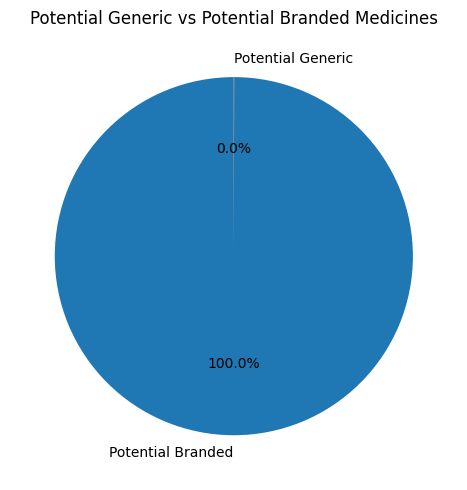

In [ ]:
medicine_type_counts = (
    df_analysis["medicine_type"]
    .value_counts()
    .reset_index()
)

medicine_type_counts.columns = [
    "medicine_type",
    "count"
]

plt.figure(figsize=(7, 5))

plt.pie(
    medicine_type_counts["count"],
    labels=medicine_type_counts["medicine_type"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "Potential Generic vs Potential Branded Medicines"
)

plt.tight_layout()
plt.show()

#Potential Generic Price vs Average Comparison Price

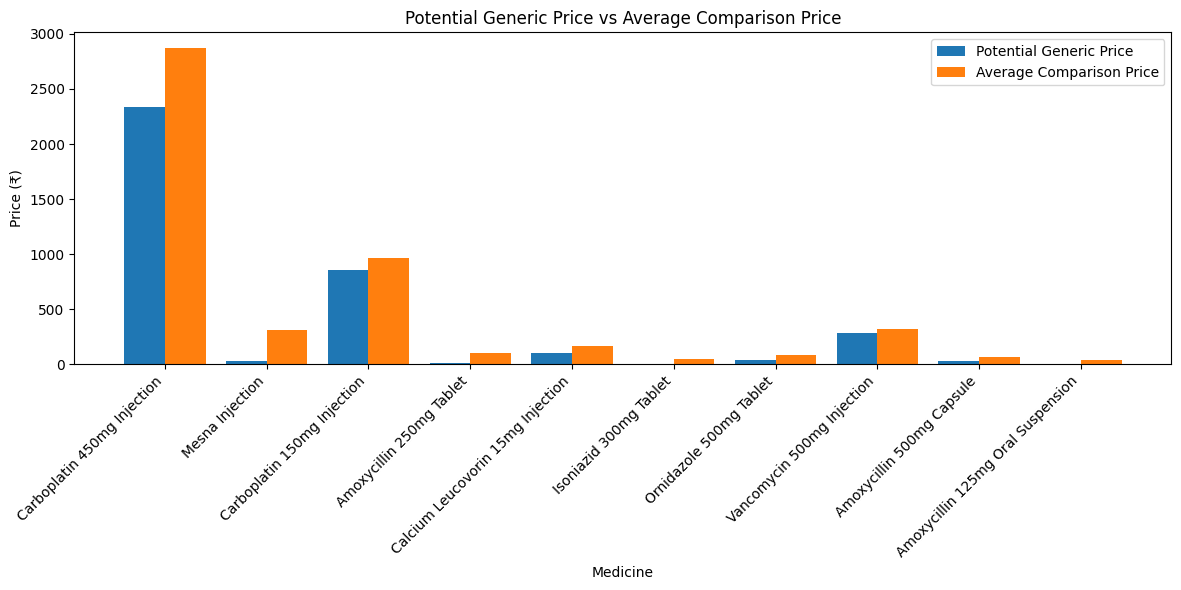

In [ ]:
top_price_comparisons = (
    final_analysis
    .sort_values(
        "price_difference",
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(12, 6))

x = range(len(top_price_comparisons))

plt.bar(
    [i - 0.2 for i in x],
    top_price_comparisons["price_inr"],
    width=0.4,
    label="Potential Generic Price"
)

plt.bar(
    [i + 0.2 for i in x],
    top_price_comparisons["average_other_price"],
    width=0.4,
    label="Average Comparison Price"
)

plt.title(
    "Potential Generic Price vs Average Comparison Price"
)

plt.xlabel("Medicine")
plt.ylabel("Price (₹)")

plt.xticks(
    x,
    top_price_comparisons["brand_name"],
    rotation=45,
    ha="right"
)

plt.legend()

plt.tight_layout()
plt.show()

#Percentage Price Difference

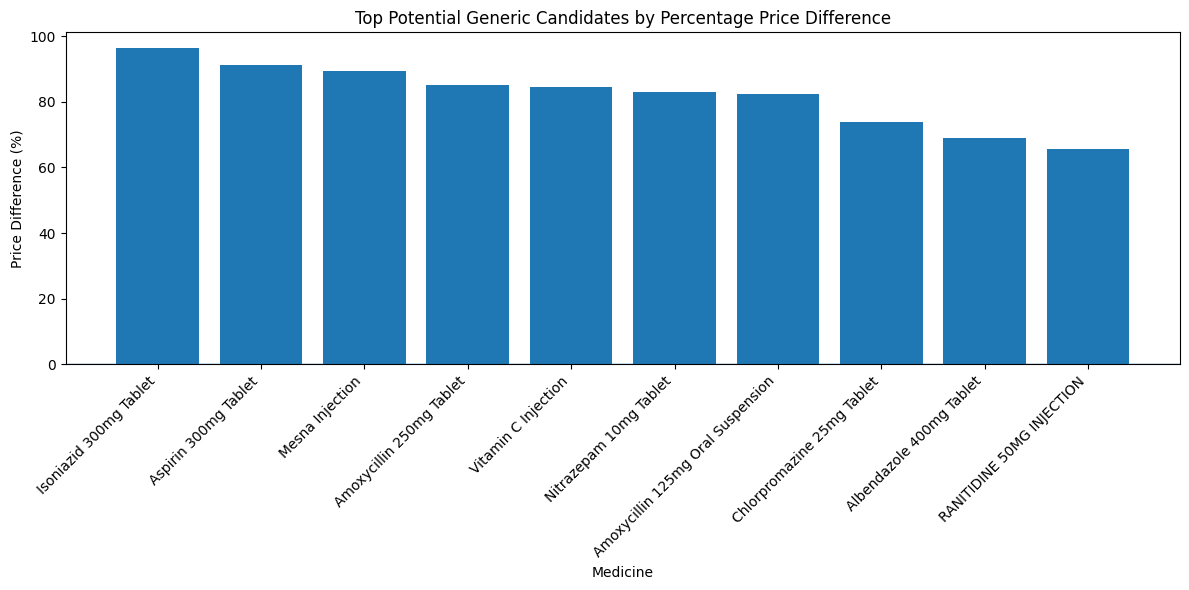

In [ ]:
top_percentage_difference = (
    final_analysis
    .sort_values(
        "price_difference_percent",
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(12, 6))

plt.bar(
    top_percentage_difference["brand_name"],
    top_percentage_difference["price_difference_percent"]
)

plt.axhline(
    y=0,
    linewidth=1
)

plt.title(
    "Top Potential Generic Candidates by Percentage Price Difference"
)

plt.xlabel("Medicine")
plt.ylabel("Price Difference (%)")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()

#Top Comparison Groups by Price Difference

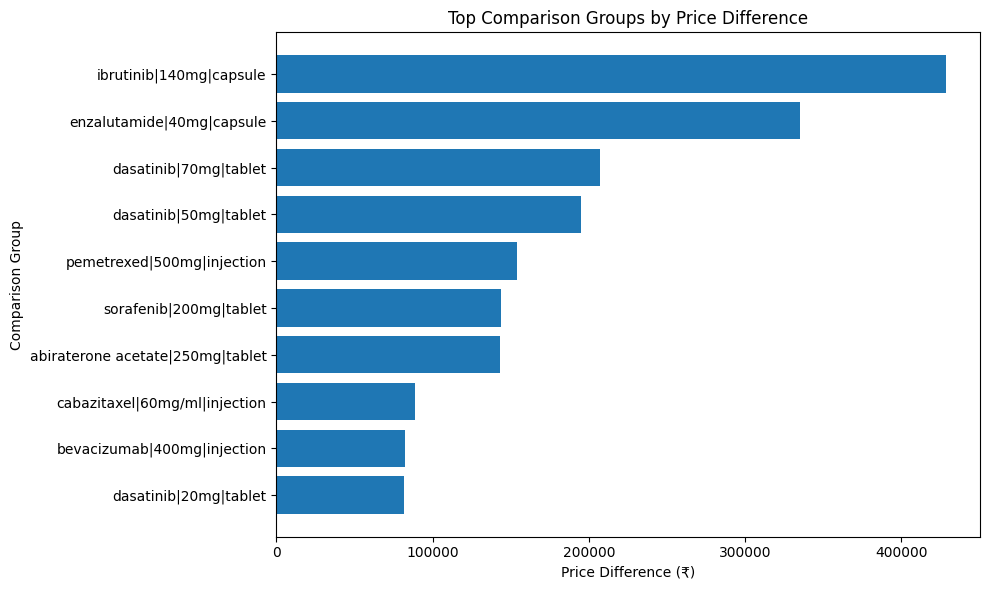

In [ ]:
# ------------------------------------------------------------
# Comparison Group Price Differences
# ------------------------------------------------------------

top_groups = (
    group_summary_sorted
    .head(10)
    .sort_values("price_difference")
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_groups["comparison_group"],
    top_groups["price_difference"]
)

plt.title(
    "Top Comparison Groups by Price Difference"
)

plt.xlabel("Price Difference (₹)")
plt.ylabel("Comparison Group")

plt.tight_layout()
plt.show()

#Price Distribution

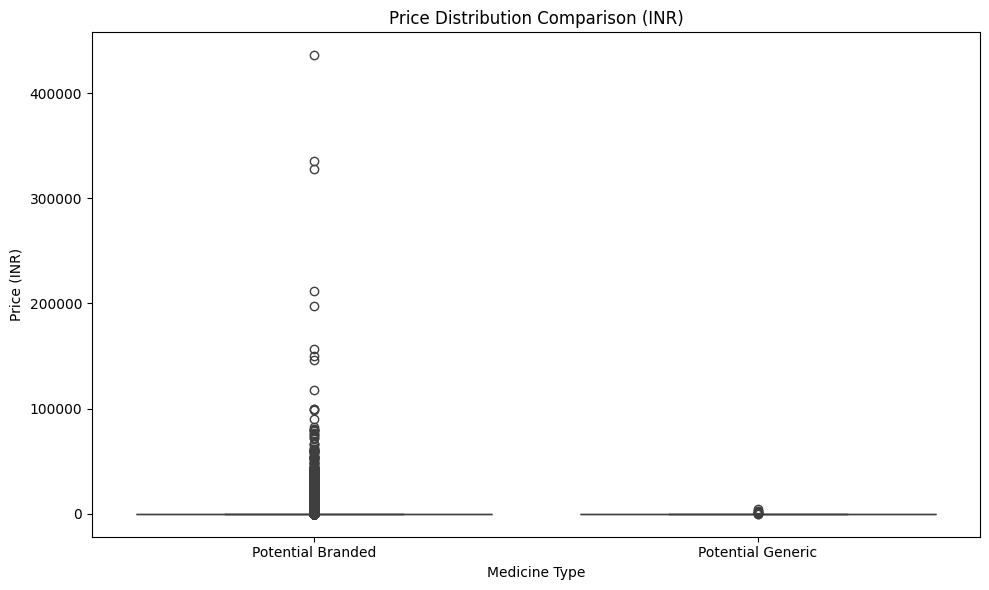

In [ ]:
# ------------------------------------------------------------
#  Price Distribution Comparison
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_analysis,
    x="medicine_type",
    y="price_inr"
)

plt.title("Price Distribution Comparison (INR)")
plt.xlabel("Medicine Type")
plt.ylabel("Price (INR)")

plt.tight_layout()
plt.show()

#8.RESULTS & INTERPRETATION

#Overall Dataset Results

In [ ]:
# ------------------------------------------------------------
#  Overall Project Results
# ------------------------------------------------------------

print("========== PROJECT RESULTS ==========")

print("Total medicines in analysis:",
      len(df_analysis))

print("Total comparison groups:",
      df_analysis["comparison_group"].nunique())

print("Potential Generic medicines:",
      (df_analysis["medicine_type"] == "Potential Generic").sum())

print("Potential Branded medicines:",
      (df_analysis["medicine_type"] == "Potential Branded").sum())

print("======================================")

========== PROJECT RESULTS ==========
Total medicines in analysis: 225731
Total comparison groups: 4344
Potential Generic medicines: 59
Potential Branded medicines: 225672


#Price Comparison Results

In [ ]:
# ------------------------------------------------------------
#  Price Comparison Results
# ------------------------------------------------------------

cheaper_count = (
    final_analysis["price_difference"] > 0
).sum()

higher_count = (
    final_analysis["price_difference"] < 0
).sum()

equal_count = (
    final_analysis["price_difference"] == 0
).sum()

print("========== PRICE COMPARISON ==========")

print("Potential Generic candidates:",
      len(final_analysis))

print("Lower than average comparison price:",
      cheaper_count)

print("Higher than average comparison price:",
      higher_count)

print("Equal to average comparison price:",
      equal_count)

print("======================================")

========== PRICE COMPARISON ==========
Potential Generic candidates: 59
Lower than average comparison price: 46
Higher than average comparison price: 13
Equal to average comparison price: 0


#Identify the Largest Observed Price Difference

In [ ]:
# ------------------------------------------------------------
#  Largest Positive Price Difference
# ------------------------------------------------------------

largest_difference = (
    final_analysis
    .sort_values(
        "price_difference_percent",
        ascending=False
    )
    .iloc[0]
)

print("Medicine with largest positive price difference:")

print(
    "Medicine:",
    largest_difference["brand_name"]
)

print(
    "Potential Generic Price: ₹",
    round(largest_difference["price_inr"], 2)
)

print(
    "Average Comparison Price: ₹",
    round(largest_difference["average_other_price"], 2)
)

print(
    "Price Difference: ₹",
    round(largest_difference["price_difference"], 2)
)

print(
    "Percentage Difference:",
    round(
        largest_difference["price_difference_percent"],
        2
    ),
    "%"
)

Medicine with largest positive price difference:
Medicine: Isoniazid 300mg Tablet
Potential Generic Price: ₹ 1.75
Average Comparison Price: ₹ 48.2
Price Difference: ₹ 46.45
Percentage Difference: 96.37 %


#Identify Cases Where Potential Generic Was More Expensive

In [ ]:
# ------------------------------------------------------------
# Potential Generic Candidates With Higher Prices
# ------------------------------------------------------------

higher_price_cases = final_analysis[
    final_analysis["price_difference"] < 0
].copy()

print(
    "Potential Generic candidates with higher prices:"
)

print(
    higher_price_cases[
        [
            "brand_name",
            "price_inr",
            "average_other_price",
            "price_difference",
            "price_difference_percent"
        ]
    ].to_string(index=False)
)

Potential Generic candidates with higher prices:
                         brand_name  price_inr  average_other_price  price_difference  price_difference_percent
         Oxaliplatin 100mg Infusion    4670.33          4619.813333        -50.516667                 -1.093479
  Calcium Leucovorin 50mg Injection     288.12           284.762222         -3.357778                 -1.179151
           Amikacin 250mg Injection      38.70            37.606587         -1.093413                 -2.907504
              Orlistat 120mg Tablet     375.00           350.868333        -24.131667                 -6.877699
            Leflunomide 20mg Tablet     271.25           252.339687        -18.910313                 -7.493991
           Mitomycin 40mg Injection    2980.00          2245.690000       -734.310000                -32.698636
         Chlorpromazine 10mg Tablet       4.04             2.940000         -1.100000                -37.414966
           Mitomycin 10mg Injection     593.00         

#Final Interpretation

In [ ]:
# ============================================================
#  BEST PRICE CASES FOR POTENTIAL GENERIC-NAME MEDICINES
# ============================================================

# Keep only cases where the potential generic-name medicine
# is cheaper than the average price of comparison medicines
best_generic_cases = final_analysis[
    final_analysis["price_difference"] > 0
].copy()

# Sort from highest percentage price difference to lowest
best_generic_cases = best_generic_cases.sort_values(
    "price_difference_percent",
    ascending=False
).reset_index(drop=True)

# Select the most useful columns
best_generic_cases = best_generic_cases[
    [
        "comparison_group",
        "brand_name",
        "manufacturer",
        "price_inr",
        "average_other_price",
        "price_difference",
        "price_difference_percent"
    ]
].copy()

# Round values
best_generic_cases = best_generic_cases.round({
    "price_inr": 2,
    "average_other_price": 2,
    "price_difference": 2,
    "price_difference_percent": 2
})

print("========== BEST POTENTIAL GENERIC CASES ==========")
print(
    best_generic_cases.to_string(index=False)
)
print("===================================================")

========== BEST POTENTIAL GENERIC CASES ==========
                 comparison_group                        brand_name                          manufacturer  price_inr  average_other_price  price_difference  price_difference_percent
           isoniazid|300mg|tablet            Isoniazid 300mg Tablet            Cadila Pharmaceuticals Ltd       1.75                48.20             46.45                     96.37
             aspirin|300mg|tablet              Aspirin 300mg Tablet             Bini Laboratories Pvt Ltd       2.00                22.67             20.67                     91.18
            mesna|200mg|injection                   Mesna Injection                          Zydus Cadila      33.05               315.47            282.42                     89.52
         amoxycillin|250mg|tablet          Amoxycillin 250mg Tablet               Makers Laboratories Ltd      15.00               100.26             85.26                     85.04
        vitamin c|150mg|injection      

In [ ]:
# ------------------------------------------------------------
#  Results Summary
# ------------------------------------------------------------

print("\n========== RESULTS & INTERPRETATION ==========\n")

print(
    "The analysis identified",
    len(generic_candidates),
    "potential generic-name medicines based on the "
    "project-defined name-to-ingredient matching rule."
)

print(
    "These medicines were compared with other medicines "
    "having the same comparison group, defined using "
    "active ingredient, strength, and dosage form."
)

print(
    cheaper_count,
    "potential generic candidates had a lower price than "
    "the average price of the comparison medicines."
)

print(
    higher_count,
    "potential generic candidates had a higher price than "
    "the average comparison price."
)

print(
    "The results show that price differences exist between "
    "medicines within comparable groups, but the difference "
    "is not the same for every medicine."
)

print(
    "\n=============================================="
)


========== RESULTS & INTERPRETATION ==========

The analysis identified 59 potential generic-name medicines based on the project-defined name-to-ingredient matching rule.
These medicines were compared with other medicines having the same comparison group, defined using active ingredient, strength, and dosage form.
46 potential generic candidates had a lower price than the average price of the comparison medicines.
13 potential generic candidates had a higher price than the average comparison price.
The results show that price differences exist between medicines within comparable groups, but the difference is not the same for every medicine.



In [ ]:
# Save the final processed dataset
df_analysis.to_csv(
    "final_processed_medicine_dataset.csv",
    index=False
)

print("File saved successfully!")
print("Rows:", len(df_analysis))
print("Columns:", len(df_analysis.columns))

File saved successfully!
Rows: 225731
Columns: 15


In [ ]:
# Save the final processed dataset
df_analysis.to_csv(
    "final_processed_medicine_dataset.csv",
    index=False
)

print("File saved successfully!")
print("Rows:", len(df_analysis))
print("Columns:", len(df_analysis.columns))

File saved successfully!
Rows: 225731
Columns: 15


In [ ]:
from google.colab import files

files.download("final_processed_medicine_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
print(
    df_analysis["medicine_type"].value_counts()
)

medicine_type
Potential Branded    225672
Potential Generic        59
Name: count, dtype: int64


In [ ]:
generic_rows = df_analysis[
    df_analysis["medicine_type"] == "Potential Generic"
]

print(
    generic_rows[
        [
            "brand_name",
            "primary_ingredient",
            "price_inr",
            "medicine_type"
        ]
    ].to_string(index=False)
)

                         brand_name   primary_ingredient  price_inr     medicine_type
            Adenosine 3mg Injection            Adenosine     208.02 Potential Generic
           Albendazole 400mg Tablet          Albendazole       9.58 Potential Generic
                   Alfuzosin Tablet            Alfuzosin     165.00 Potential Generic
           Amikacin 250mg Injection             Amikacin      38.70 Potential Generic
  Amoxycillin 125mg Oral Suspension          Amoxycillin       7.50 Potential Generic
            Amoxycillin 125mg Syrup          Amoxycillin      24.50 Potential Generic
           Amoxycillin 125mg Tablet          Amoxycillin      12.10 Potential Generic
         Amoxycillin  250mg Capsule          Amoxycillin      38.00 Potential Generic
           Amoxycillin 250mg Tablet          Amoxycillin      15.00 Potential Generic
          Amoxycillin 500mg Capsule          Amoxycillin      31.90 Potential Generic
         Ampicillin 125mg Dry Syrup           Ampicill

In [ ]:
df_analysis.to_csv(
    "final_processed_medicine_dataset.csv",
    index=False
)

from google.colab import files

files.download(
    "final_processed_medicine_dataset.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>